In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
train.shape

(891, 12)

In [5]:
test.shape

(418, 11)

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<Axes: xlabel='Survived', ylabel='count'>

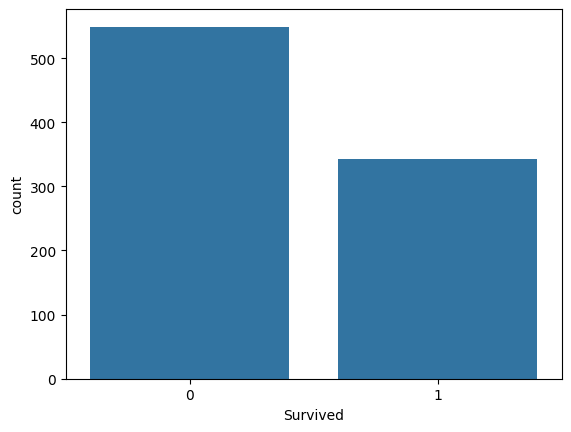

In [9]:
import seaborn as sns
sns.countplot(x='Survived',data=train)

In [10]:
train['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [11]:
train.groupby('Survived')['Survived'].count()/train.shape[0]*100

Survived
0    61.616162
1    38.383838
Name: Survived, dtype: float64

<Axes: ylabel='count'>

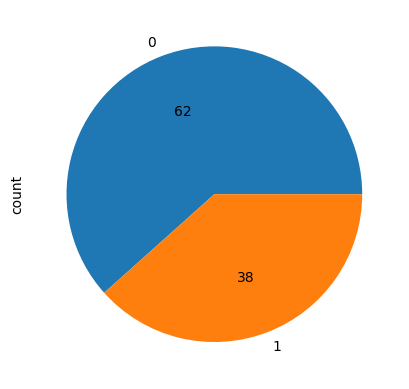

In [12]:
train['Survived'].value_counts().plot(kind='pie',autopct='%.f')

<Axes: xlabel='Sex', ylabel='count'>

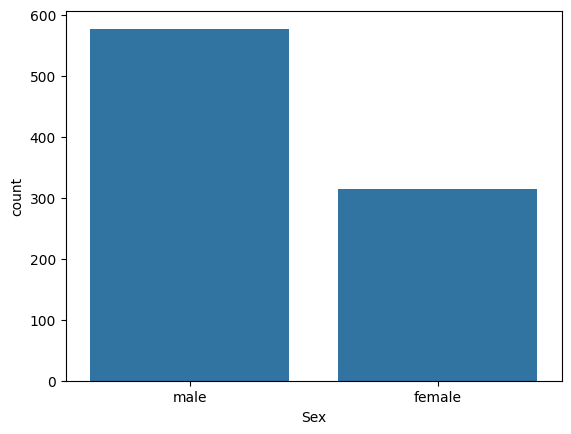

In [13]:
sns.countplot(x='Sex',data=train)

In [14]:
train.groupby('Sex')['Sex'].count()/train.shape[0]*100

Sex
female    35.241302
male      64.758698
Name: Sex, dtype: float64

<Axes: ylabel='count'>

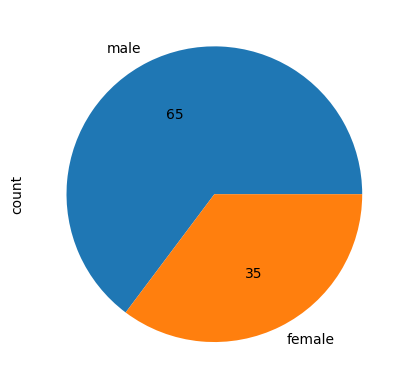

In [15]:
train['Sex'].value_counts().plot(kind='pie',autopct='%.f')

In [16]:
pd.crosstab(train['Sex'],train['Survived'])

Survived,0,1
Sex,,
female,81,233
male,468,109


<Axes: xlabel='Sex', ylabel='Survived'>

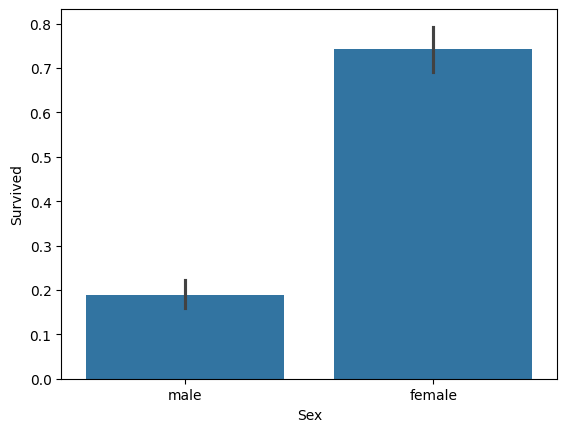

In [17]:
sns.barplot(x='Sex',y='Survived',data=train)

In [18]:
females = train[train['Sex']=='female']['Survived'].value_counts()
females.values[1]
print("female survival rate: ", ((females[1]) / ((females[0])+(females[1]) )))

female survival rate:  0.7420382165605095


In [19]:
males = train[train['Sex']=='male']['Survived'].value_counts()
males.values[1]
print("male survival rate: ", ((males[1]) / ((males[0])+(males[1]) )))

male survival rate:  0.18890814558058924


In [20]:
train.groupby('Sex')['Survived'].mean()*100

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

<Axes: xlabel='Pclass'>

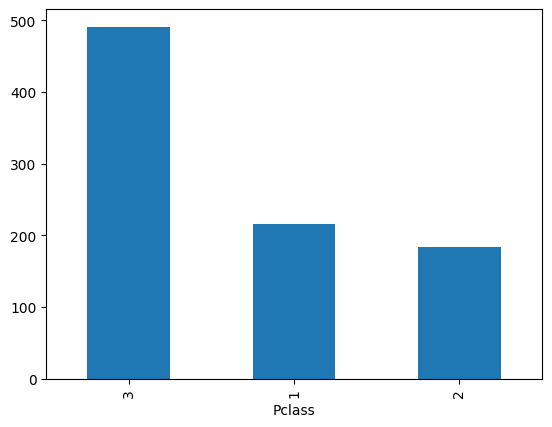

In [21]:
train['Pclass'].value_counts().plot(kind='bar')

In [22]:
train.groupby('Pclass')['Pclass'].count()/train.shape[0]*100

Pclass
1    24.242424
2    20.650954
3    55.106622
Name: Pclass, dtype: float64

<Axes: ylabel='count'>

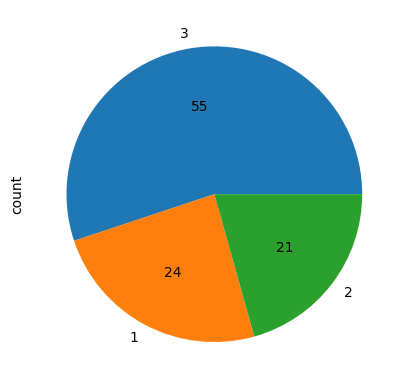

In [23]:
train['Pclass'].value_counts().plot(kind='pie',autopct='%.f')

In [24]:
pd.crosstab(train['Pclass'],train['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [25]:
train.groupby('Pclass')['Survived'].mean()*100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

<Axes: xlabel='Pclass', ylabel='Survived'>

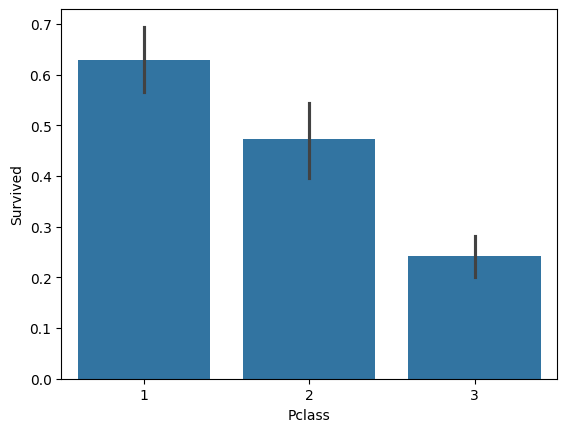

In [26]:
sns.barplot(x='Pclass',y='Survived',data=train)

<Axes: xlabel='Embarked', ylabel='count'>

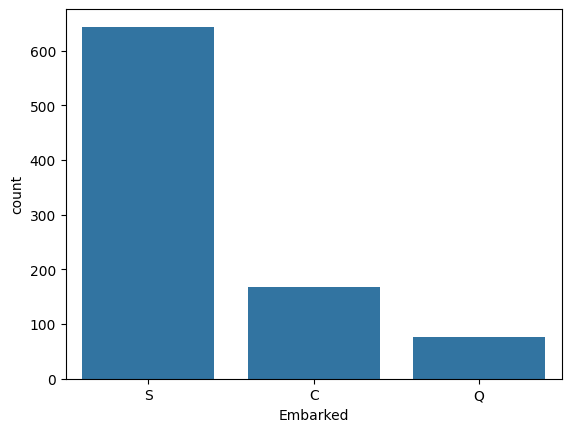

In [27]:
#Embarked: S (Southampton), C (Cherbourg), and Q (Queenstown).
sns.countplot(x='Embarked',data=train)

In [28]:
train.groupby('Embarked')['Embarked'].count()/train.shape[0]*100

Embarked
C    18.855219
Q     8.641975
S    72.278339
Name: Embarked, dtype: float64

<Axes: ylabel='count'>

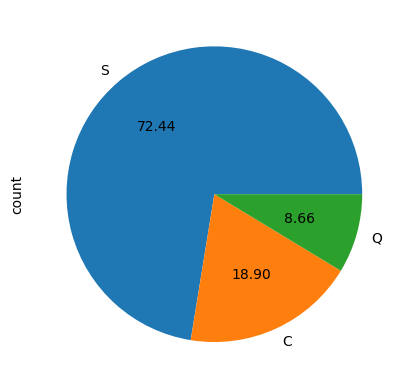

In [29]:
train['Embarked'].value_counts().plot(kind='pie',autopct='%.2f')

In [30]:
pd.crosstab(train['Embarked'],train['Survived'])

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,217


In [31]:
train.groupby('Embarked')['Survived'].mean()*100

Embarked
C    55.357143
Q    38.961039
S    33.695652
Name: Survived, dtype: float64

<Axes: xlabel='Embarked', ylabel='Survived'>

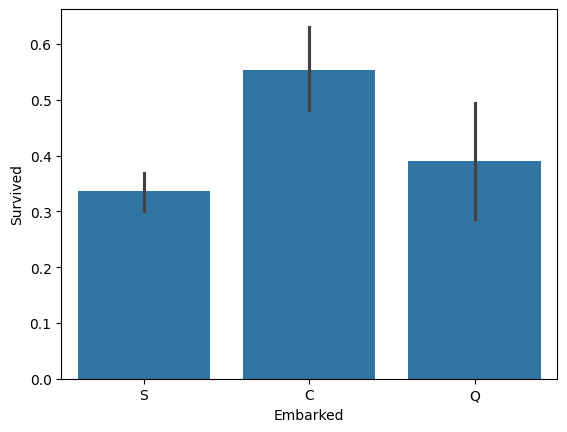

In [32]:
sns.barplot(x='Embarked',y='Survived',data=train)

In [33]:
import matplotlib.pyplot as plt

<Axes: ylabel='Age'>

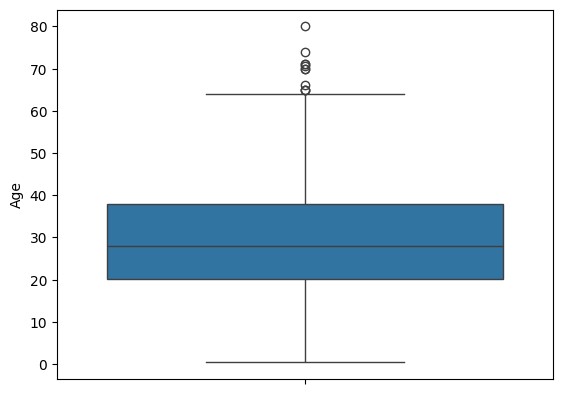

In [34]:
sns.boxplot(train['Age'])

<Axes: xlabel='Sex', ylabel='Age'>

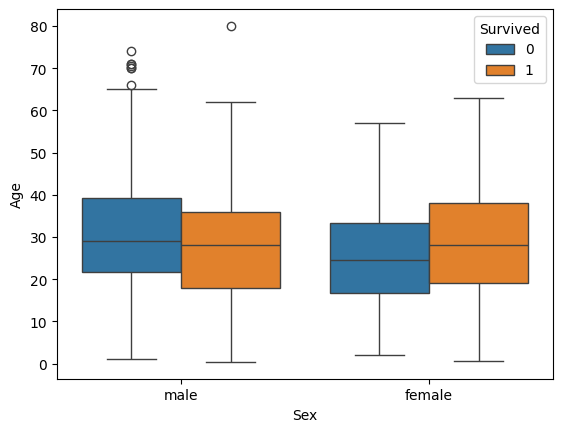

In [35]:
sns.boxplot(x='Sex',y='Age',data=train,hue='Survived')

<Axes: xlabel='Pclass', ylabel='Age'>

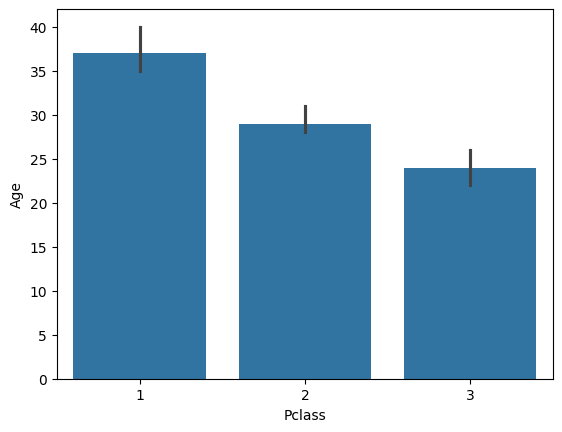

In [36]:
sns.barplot(x='Pclass',y='Age',data=train,estimator='median')

<Axes: xlabel='Survived', ylabel='Age'>

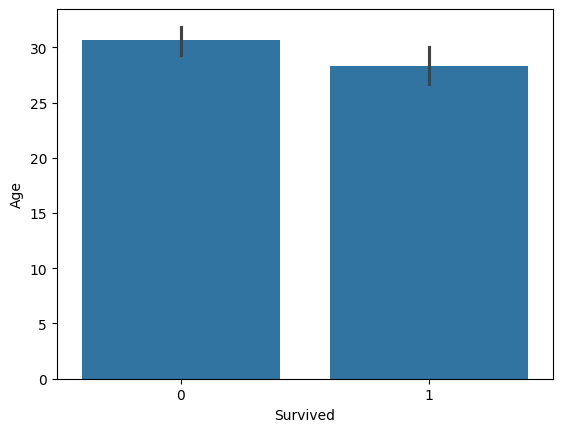

In [37]:
sns.barplot(x='Survived',y='Age',data=train,estimator='mean')

(array([ 64., 115., 230., 155.,  86.,  42.,  17.,   5.]),
 array([ 0.42  , 10.3675, 20.315 , 30.2625, 40.21  , 50.1575, 60.105 ,
        70.0525, 80.    ]),
 <BarContainer object of 8 artists>)

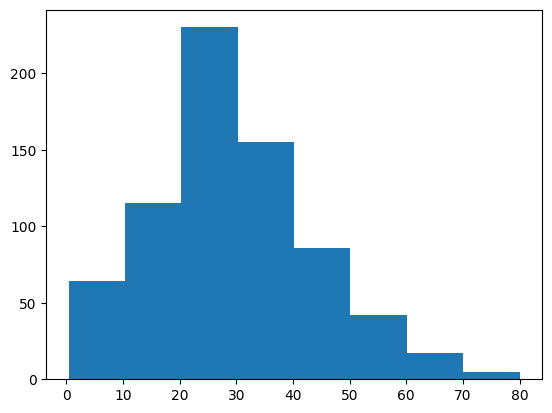

In [38]:
plt.hist(train['Age'],bins=8)

(array([38., 44., 84., 69., 33., 17.,  4.,  1.]),
 array([ 0.42  , 10.3675, 20.315 , 30.2625, 40.21  , 50.1575, 60.105 ,
        70.0525, 80.    ]),
 <BarContainer object of 8 artists>)

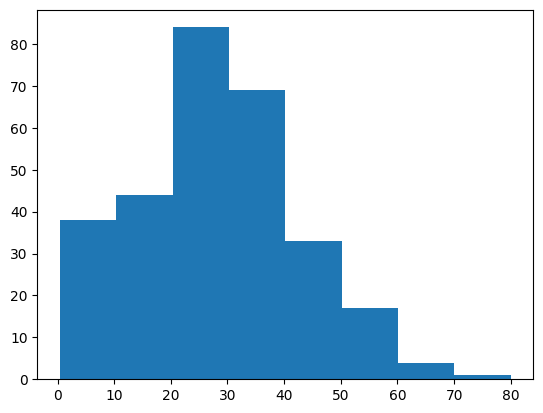

In [39]:
plt.hist(train[train['Survived']==1]['Age'],bins=8)

(array([ 26.,  59., 129.,  93.,  57.,  33.,  17.,  10.]),
 array([ 1.   , 10.125, 19.25 , 28.375, 37.5  , 46.625, 55.75 , 64.875,
        74.   ]),
 <BarContainer object of 8 artists>)

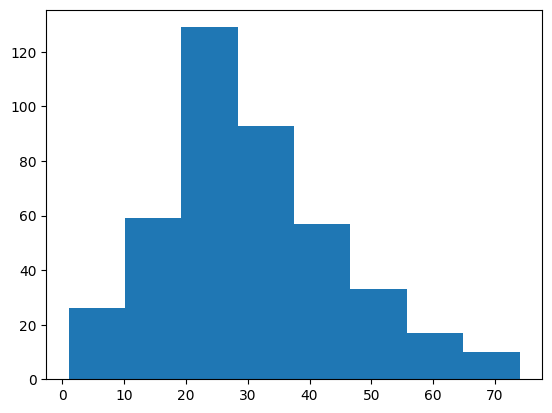

In [40]:
plt.hist(train[train['Survived']==0]['Age'],bins=8)

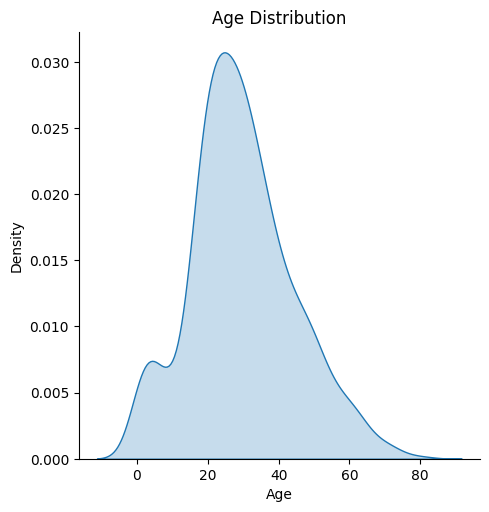

In [41]:
sns.displot(train['Age'],kind='kde',fill=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

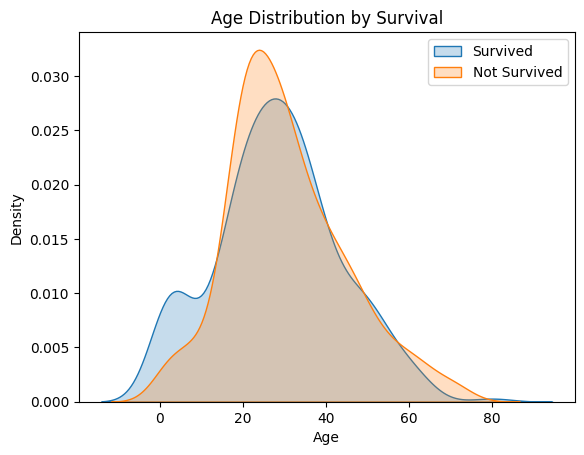

In [42]:
# sns.displot(train[train['Survived']==1]['Age'],kind='kde')
# sns.displot(train[train['Survived']==0]['Age'],kind='kde')
# sns.displot() is a figure-level function, meaning: It creates a new figure every time, So you cannot overlay plots using it

sns.kdeplot(train[train['Survived']==1]['Age'],label='Survived',fill=True)
sns.kdeplot(train[train['Survived']==0]['Age'],label='Not Survived',fill=True)

plt.legend()
plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

In [43]:
pd.crosstab(train['Pclass'],train['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


<Axes: xlabel='Survived', ylabel='Pclass'>

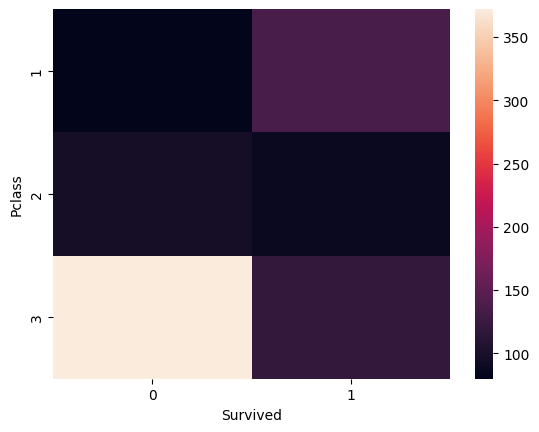

In [44]:
sns.heatmap(pd.crosstab(train['Pclass'],train['Survived']))

In [45]:
train.groupby('SibSp')['SibSp'].count()/train.shape[0]*100

SibSp
0    68.237935
1    23.456790
2     3.142536
3     1.795735
4     2.020202
5     0.561167
8     0.785634
Name: SibSp, dtype: float64

<Axes: ylabel='count'>

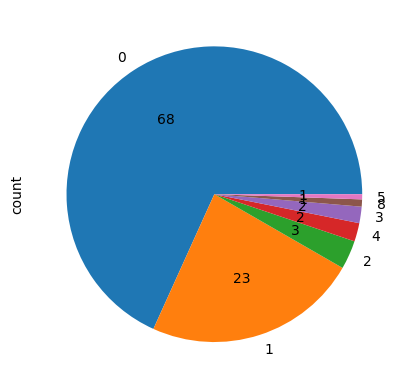

In [46]:
train['SibSp'].value_counts().plot(kind='pie',autopct='%.f')

In [47]:
pd.crosstab(train['SibSp'],train['Survived'])

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


In [48]:
train.groupby('SibSp')['Survived'].mean()*100

SibSp
0    34.539474
1    53.588517
2    46.428571
3    25.000000
4    16.666667
5     0.000000
8     0.000000
Name: Survived, dtype: float64

In [49]:
train.groupby('Parch')['Parch'].count()/train.shape[0]*100

Parch
0    76.094276
1    13.243547
2     8.978676
3     0.561167
4     0.448934
5     0.561167
6     0.112233
Name: Parch, dtype: float64

<Axes: ylabel='count'>

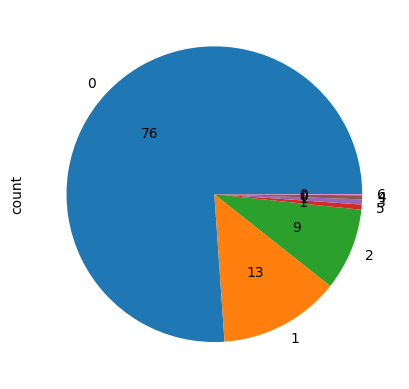

In [50]:
train['Parch'].value_counts().plot(kind='pie',autopct='%.f')

In [51]:
pd.crosstab(train['Pclass'],train['Embarked'])

Embarked,C,Q,S
Pclass,,,
1,85,2,127
2,17,3,164
3,66,72,353


In [52]:
df = pd.crosstab(train['Pclass'],train['Sex'])
df["female_%age"] = (df['female'] / (df['male']+df['female']))*100
df['total_survival_%age'] = train.groupby('Pclass')['Survived'].mean()*100
df

Sex,female,male,female_%age,total_survival_%age
Pclass,,,,
1,94,122,43.518519,62.962963
2,76,108,41.304348,47.282609
3,144,347,29.327902,24.236253


In [53]:
train.groupby('Pclass')['Sex'].value_counts(normalize=True)*100

Pclass  Sex   
1       male      56.481481
        female    43.518519
2       male      58.695652
        female    41.304348
3       male      70.672098
        female    29.327902
Name: proportion, dtype: float64

In [87]:
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [55]:
train.drop(['Name','Ticket','Cabin'],axis=1,inplace=True)
test.drop(['Name','Ticket','Cabin'],axis=1,inplace=True)

KeyError: "['Name', 'Ticket', 'Cabin'] not found in axis"

In [56]:
train

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,0,0,13.0000,S
887,888,1,1,female,19.0,0,0,30.0000,S
888,889,0,3,female,NaN,1,2,23.4500,S
889,890,1,1,male,26.0,0,0,30.0000,C


In [57]:
test

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,892,3,male,34.5,0,0,7.8292,Q
1,893,3,female,47.0,1,0,7.0000,S
2,894,2,male,62.0,0,0,9.6875,Q
3,895,3,male,27.0,0,0,8.6625,S
4,896,3,female,22.0,1,1,12.2875,S
...,...,...,...,...,...,...,...,...
413,1305,3,male,NaN,0,0,8.0500,S
414,1306,1,female,39.0,0,0,108.9000,C
415,1307,3,male,38.5,0,0,7.2500,S
416,1308,3,male,NaN,0,0,8.0500,S


In [58]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(2)
memory usage: 62.8+ KB


In [59]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Sex          418 non-null    object 
 3   Age          332 non-null    float64
 4   SibSp        418 non-null    int64  
 5   Parch        418 non-null    int64  
 6   Fare         417 non-null    float64
 7   Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 26.3+ KB


In [ ]:
train['Age'].fillna(train['Age'].median(),inplace=True)
test['Age'].fillna(test['Age'].median(),inplace=True)

In [ ]:
train.info()

In [ ]:
test.info()

In [ ]:
train['Embarked'].fillna(train['Embarked'].mode()[0],inplace=True)

In [ ]:
train['Embarked'].isnull().sum()

In [ ]:
train.info()

In [ ]:
train['Sex'] = train['Sex'].map({'male':0, 'female':1})
test['Sex'] = test['Sex'].map({'male':0, 'female':1})

train = pd.get_dummies(train, columns=['Embarked'], drop_first=True)
test = pd.get_dummies(test, columns=['Embarked'], drop_first=True)

In [ ]:
test.isnull().sum()
test['Fare'].fillna(test['Fare'].median(),inplace=True)

In [ ]:
X = train.drop(['Survived', 'PassengerId'], axis=1)
y = train['Survived']

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

In [ ]:
from sklearn.metrics import accuracy_score
X_test = test.drop(['PassengerId'], axis=1)
pred = model.predict(X_test)

In [ ]:
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': pred
})

submission.to_csv('submission.csv', index=False)